
# Funding Carry Baseline Analysis Notebook

這份 notebook 對應 `FUNDING_CARRY_V1_FINAL_STRATEGY_DECISION_NOTE_20260224.md`，目標是：

1. 用同一套資料重現 baseline 結論
2. 示範分析 Funding Carry 時應該看的關鍵數據
3. 用圖表把「收益來源 / 成本 / 風險 / 曝險對齊」講清楚

> 建議使用 `Quant` conda 環境執行。


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.feather as feather
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

print("Libraries loaded.")


Libraries loaded.



## 1) 選擇分析 run
- `run_id`：特定回測結果
- 若不指定，會自動找最新且資料完整的 run

In [2]:

LOG_ROOT_CANDIDATES = [
    Path(r"D:/QTrading.Cpp/out/build/x64-release/QTrading.Service/logs")
]

# 指定 run，例如: "20260210_232343"；設成 None 則自動抓最新完整 run
RUN_ID = None

REQUIRED_FILES = [
    "Account.arrow",
    "OrderEvent.arrow",
    "FundingEvent.arrow",
    "MarketEvent.arrow",
    "Position.arrow",
    "AccountEvent.arrow",
]


def is_complete_run(run_dir: Path) -> bool:
    return all((run_dir / name).exists() for name in REQUIRED_FILES)


def find_run_dir(run_id: str | None = None) -> Path:
    if run_id:
        for root in LOG_ROOT_CANDIDATES:
            candidate = root / run_id
            if candidate.exists() and is_complete_run(candidate):
                return candidate
        raise FileNotFoundError(f"Run id not found or incomplete: {run_id}")

    candidates: list[Path] = []
    for root in LOG_ROOT_CANDIDATES:
        if root.exists():
            for run in root.iterdir():
                if run.is_dir() and is_complete_run(run):
                    candidates.append(run)

    if not candidates:
        raise FileNotFoundError("No complete run directory found in configured log roots.")

    return max(candidates, key=lambda p: p.stat().st_mtime)


RUN_DIR = find_run_dir(RUN_ID)
RUN_DIR


WindowsPath('D:/QTrading.Cpp/out/build/x64-release/QTrading.Service/logs/20260224_010954')


## 2) 載入資料與完整性檢查

### 重點

- 各事件表（Account / OrderEvent / FundingEvent / MarketEvent / Position）是否齊全
- 時間範圍是否一致
- row 數量是否合理
- 若 `MarketEvent` 中 spot/perp 同時存在的比率太低，basis 相關分析不可信


In [3]:

def read_arrow(name: str, columns: list[str] | None = None) -> pd.DataFrame:
    table = feather.read_table(RUN_DIR / name, columns=columns)
    return table.to_pandas()


account = read_arrow(
    "Account.arrow",
    columns=[
        "timestamp", "balance", "total_ledger_value", "total_cash_balance"
    ],
)
order_event = read_arrow(
    "OrderEvent.arrow",
    columns=[
        "ts", "symbol", "event_type", "exec_qty", "exec_price", "fee", "is_taker"
    ],
)
funding = read_arrow(
    "FundingEvent.arrow",
    columns=["ts", "symbol", "funding_time", "rate", "funding"],
)
market = read_arrow(
    "MarketEvent.arrow",
    columns=["ts", "symbol", "has_kline", "close", "volume"],
)
position = read_arrow(
    "Position.arrow",
    columns=["timestamp", "symbol", "instrument_type", "is_long", "notional"],
)
account_event = read_arrow(
    "AccountEvent.arrow",
    columns=["ts", "symbol", "event_type", "wallet_delta", "ledger"],
)

account["datetime"] = pd.to_datetime(account["timestamp"], unit="ms", utc=True)
order_event["datetime"] = pd.to_datetime(order_event["ts"], unit="ms", utc=True)
funding["datetime"] = pd.to_datetime(funding["ts"], unit="ms", utc=True)
funding["funding_dt"] = pd.to_datetime(funding["funding_time"], unit="ms", utc=True)
market["datetime"] = pd.to_datetime(market["ts"], unit="ms", utc=True)
position["datetime"] = pd.to_datetime(position["timestamp"], unit="ms", utc=True)
account_event["datetime"] = pd.to_datetime(account_event["ts"], unit="ms", utc=True)

summary_df = pd.DataFrame(
    {
        "dataset": ["account", "order_event", "funding", "market", "position", "account_event"],
        "rows": [len(account), len(order_event), len(funding), len(market), len(position), len(account_event)],
        "start": [
            account["datetime"].min(),
            order_event["datetime"].min(),
            funding["datetime"].min(),
            market["datetime"].min(),
            position["datetime"].min(),
            account_event["datetime"].min(),
        ],
        "end": [
            account["datetime"].max(),
            order_event["datetime"].max(),
            funding["datetime"].max(),
            market["datetime"].max(),
            position["datetime"].max(),
            account_event["datetime"].max(),
        ],
    }
)

spot_perp_check = (
    market[market["has_kline"] == True]
    .pivot_table(index="ts", columns="symbol", values="close", aggfunc="last")
)
spot_col = [c for c in spot_perp_check.columns if "SPOT" in c]
perp_col = [c for c in spot_perp_check.columns if "PERP" in c]
both_ok_ratio = np.nan
if spot_col and perp_col:
    both_ok_ratio = float((spot_perp_check[spot_col[0]].notna() & spot_perp_check[perp_col[0]].notna()).mean())

print(f"Run dir: {RUN_DIR}")
print(f"Spot+Perp same-timestamp availability ratio: {both_ok_ratio:.2%}")
display(summary_df)


Run dir: D:\QTrading.Cpp\out\build\x64-release\QTrading.Service\logs\20260224_010954
Spot+Perp same-timestamp availability ratio: 99.79%


,dataset,rows,start,end
0,account,1548205,2023-02-03 00:00:00.010000+00:00,2026-02-17 00:16:00+00:00
1,order_event,1733,2023-02-17 00:01:00+00:00,2026-02-17 00:16:00+00:00
2,funding,3245,2023-02-17 08:02:00+00:00,2026-02-03 00:00:00+00:00
3,market,3164356,2023-02-03 00:00:00.010000+00:00,2026-02-19 00:00:00+00:00
4,position,3096403,2023-02-17 00:02:00+00:00,2026-02-17 00:16:00+00:00
5,account_event,1549563,2023-02-03 00:00:00.010000+00:00,2026-02-17 00:16:00+00:00


## 無交易狀態診斷（訂單事件覆蓋率）

此模組回答一個關鍵問題：**策略是否在運行期間停止交易？**

解讀方法：

- `order_event_end` 與 `run_end`：如果差距較大，則執行可能已停止很長時間
- `|net|/gross` 與 `rebalance_threshold(1%)`：當比率低於門檻時，風險提前回報可能會抑制再平衡
- 紅色垂直線 = 最後一個 `order_event` 時間戳記

如果在紅色垂直線之後出現一條長長的右尾，且沒有新的訂單事件，則此運行已進入**無交易狀態**


,metric,value
0,run_start,2023-02-03 00:00:00.010000+00:00
1,run_end,2026-02-19 00:00:00+00:00
2,order_event_start,2023-02-17 00:01:00+00:00
3,order_event_end,2026-02-17 00:16:00+00:00
4,order_event_rows,1733
5,order_to_run_gap_days,1.988889


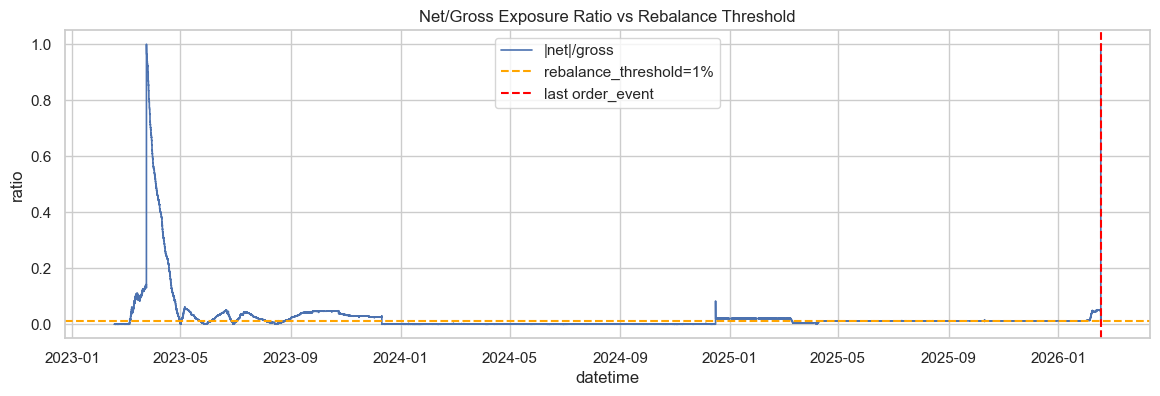

,metric,value
0,post_order_points,1.000000
1,post_order_ratio_median,1.000000
2,post_order_ratio_max,1.000000
3,post_order_ratio_above_1pct_count,1.000000


In [4]:
# no_trade_diagnostics_v1
RUN_END_TS = summary_df["end"].max()
ORDER_END_TS = order_event["datetime"].max() if not order_event.empty else pd.NaT
ORDER_START_TS = order_event["datetime"].min() if not order_event.empty else pd.NaT

gap_days = np.nan
if pd.notna(RUN_END_TS) and pd.notna(ORDER_END_TS):
    gap_days = (RUN_END_TS - ORDER_END_TS).total_seconds() / 86400.0

coverage_diag = pd.DataFrame(
    [
        {"metric": "run_start", "value": summary_df["start"].min()},
        {"metric": "run_end", "value": RUN_END_TS},
        {"metric": "order_event_start", "value": ORDER_START_TS},
        {"metric": "order_event_end", "value": ORDER_END_TS},
        {"metric": "order_event_rows", "value": int(len(order_event))},
        {"metric": "order_to_run_gap_days", "value": gap_days},
    ]
)
display(coverage_diag)

if pd.notna(gap_days) and gap_days > 30:
    display(Markdown(f"**Alert:** order events stopped ~{gap_days:,.1f} days before run end."))

pair_pos = position[position["symbol"].isin(["BTCUSDT_SPOT", "BTCUSDT_PERP"])].copy()
if pair_pos.empty:
    display(Markdown("No BTC spot/perp positions found for exposure diagnostics."))
else:
    pair_pos["signed_notional"] = pair_pos["notional"] * np.where(pair_pos["is_long"], 1.0, -1.0)
    exposure = (
        pair_pos.groupby("datetime", as_index=False)
        .agg(
            net_exposure=("signed_notional", "sum"),
            gross_exposure=("notional", lambda x: np.abs(x).sum()),
        )
        .sort_values("datetime")
    )
    exposure["net_over_gross"] = (
        exposure["net_exposure"].abs() / exposure["gross_exposure"].replace(0.0, np.nan)
    )

    threshold = 0.01
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(exposure["datetime"], exposure["net_over_gross"], label="|net|/gross", linewidth=1.2)
    ax.axhline(threshold, color="orange", linestyle="--", label="rebalance_threshold=1%")
    if pd.notna(ORDER_END_TS):
        ax.axvline(ORDER_END_TS, color="red", linestyle="--", label="last order_event")
    ax.set_title("Net/Gross Exposure Ratio vs Rebalance Threshold")
    ax.set_ylabel("ratio")
    ax.set_xlabel("datetime")
    ax.legend(loc="best")
    plt.show()

    if pd.notna(ORDER_END_TS):
        post = exposure[exposure["datetime"] >= ORDER_END_TS]
        if not post.empty:
            post_stats = pd.DataFrame(
                [
                    {"metric": "post_order_points", "value": int(len(post))},
                    {"metric": "post_order_ratio_median", "value": float(post["net_over_gross"].median())},
                    {"metric": "post_order_ratio_max", "value": float(post["net_over_gross"].max())},
                    {"metric": "post_order_ratio_above_1pct_count", "value": int((post["net_over_gross"] > threshold).sum())},
                ]
            )
            display(post_stats)



## 3) Baseline KPI（策略健康檢查）

### 重點

- `wallet_delta` / `annualized_return_pct`
- `funding_sum`, `total_fees`, `residual_price_basis`
- `max_drawdown_pct`
- `return_to_fees`

### 解讀方法：

1. `funding_sum` 應該是主要收益來源（不是 residual 在撐）
2. `fees` 不應過度吞噬 funding
3. `max_drawdown` 應該在可接受範圍
4. `residual/funding` 比例太大代表 carry 品質下降


In [5]:

has_total_ledger = ("total_ledger_value" in account.columns) and account["total_ledger_value"].notna().any()
equity_col = "total_ledger_value" if has_total_ledger else "balance"

start_balance = float(account[equity_col].iloc[0])
end_balance = float(account[equity_col].iloc[-1])
wallet_delta = end_balance - start_balance

cum_peak = account[equity_col].cummax()
drawdown = (account[equity_col] - cum_peak) / cum_peak.replace(0, np.nan)
max_drawdown_pct = float(drawdown.min()) if not drawdown.empty else 0.0

fills = order_event[order_event["exec_qty"] > 0].copy()
fills["notional"] = (fills["exec_qty"] * fills["exec_price"]).abs()

funding_sum = float(funding["funding"].sum())
total_fees = float(fills["fee"].sum())
residual_price_basis = wallet_delta - funding_sum + total_fees

elapsed_days = float((account["timestamp"].iloc[-1] - account["timestamp"].iloc[0]) / (1000 * 60 * 60 * 24))
total_return_pct = (end_balance / start_balance - 1.0) if start_balance > 0 else np.nan
annualized_return_pct = ((1.0 + total_return_pct) ** (365.0 / elapsed_days) - 1.0) if elapsed_days > 0 else np.nan
return_to_fees = wallet_delta / total_fees if total_fees > 0 else np.inf
residual_to_funding = abs(residual_price_basis) / (abs(funding_sum) + 1e-9)

kpi = pd.DataFrame(
    {
        "metric": [
            "equity_metric",
            "start_balance",
            "end_balance",
            "wallet_delta",
            "total_return_pct",
            "annualized_return_pct",
            "max_drawdown_pct",
            "funding_sum",
            "total_fees",
            "residual_price_basis",
            "residual_to_funding",
            "fill_count",
            "turnover",
            "return_to_fees",
            "elapsed_days",
        ],
        "value": [
            equity_col,
            start_balance,
            end_balance,
            wallet_delta,
            total_return_pct,
            annualized_return_pct,
            max_drawdown_pct,
            funding_sum,
            total_fees,
            residual_price_basis,
            residual_to_funding,
            int(len(fills)),
            float(fills["notional"].sum()),
            return_to_fees,
            elapsed_days,
        ],
    }
)

display(kpi)


,metric,value
0,equity_metric,total_ledger_value
1,start_balance,"100,000,000.000000"
2,end_balance,"108,277,580.665804"
3,wallet_delta,"8,277,580.665804"
4,total_return_pct,0.082776
5,annualized_return_pct,0.026496
6,max_drawdown_pct,-0.009368
7,funding_sum,"7,563,933.516567"
8,total_fees,"110,149.438228"
9,residual_price_basis,"823,796.587465"



## 4) Equity 曲線與 Drawdown

### 重點

- Equity 是否平滑向上
- Drawdown 是否是短暫且可承受

### 解讀方法：

- 若 Equity 斜率穩定且 DD 不深，代表策略節奏穩定
- 若 DD 長時間不恢復，代表風險控制或結構有問題


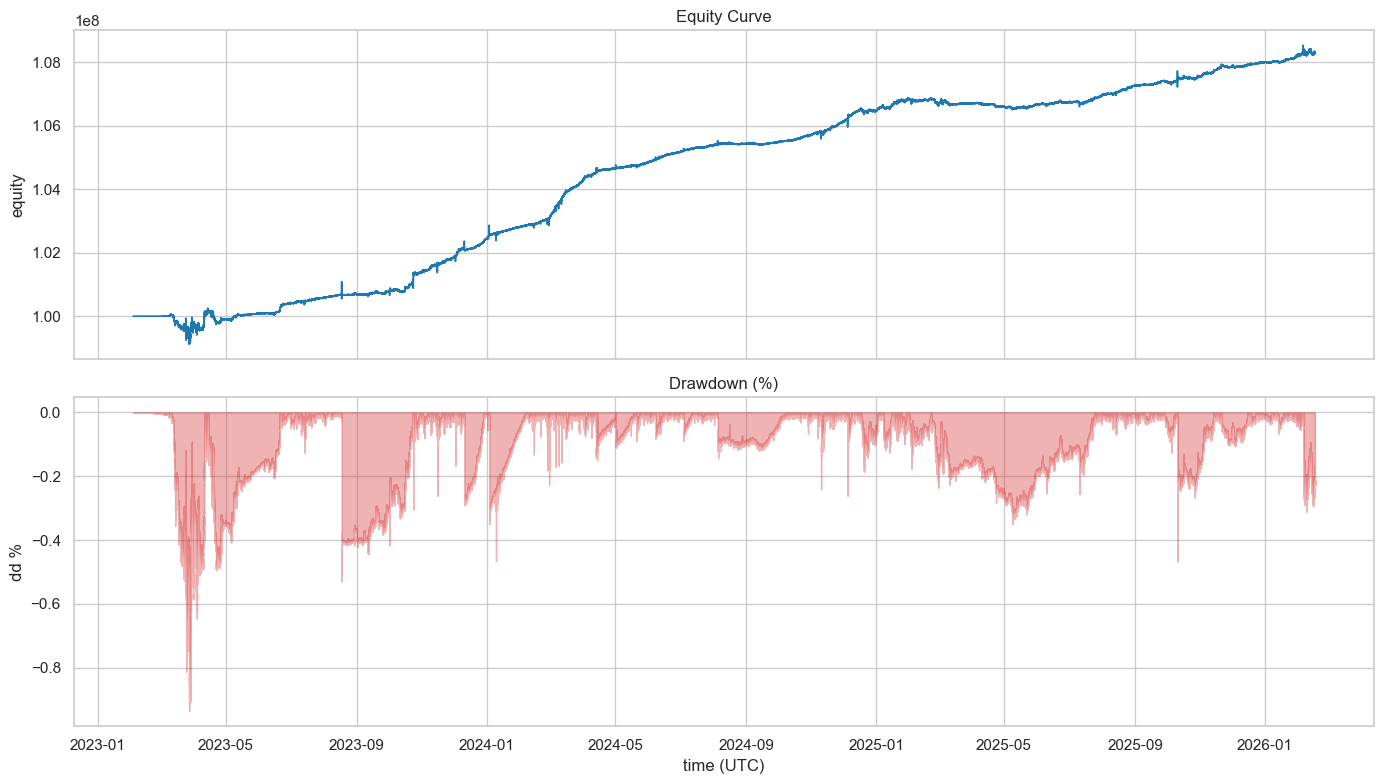

In [6]:

plot_df = account[["datetime", equity_col]].copy().sort_values("datetime")
plot_df["drawdown_pct"] = (plot_df[equity_col] / plot_df[equity_col].cummax() - 1.0) * 100.0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(plot_df["datetime"], plot_df[equity_col], color="tab:blue", lw=1.2)
axes[0].set_title("Equity Curve")
axes[0].set_ylabel("equity")

axes[1].fill_between(plot_df["datetime"], plot_df["drawdown_pct"], 0.0, color="tab:red", alpha=0.35)
axes[1].set_title("Drawdown (%)")
axes[1].set_ylabel("dd %")
axes[1].set_xlabel("time (UTC)")

plt.tight_layout()
plt.show()



## 5) PnL 拆解（月度）：Funding / Fees / Residual

### 重點

- 每個月份 `wallet_delta` 主要來自哪個分量
- residual 是否長期偏大（代表 carry 品質下降）

### 解讀方法：

- 理想：Funding 長期為主、Fees 可控、Residual 相對小
- 若 residual 長期主導，表示你賺的可能不是 carry 核心收益


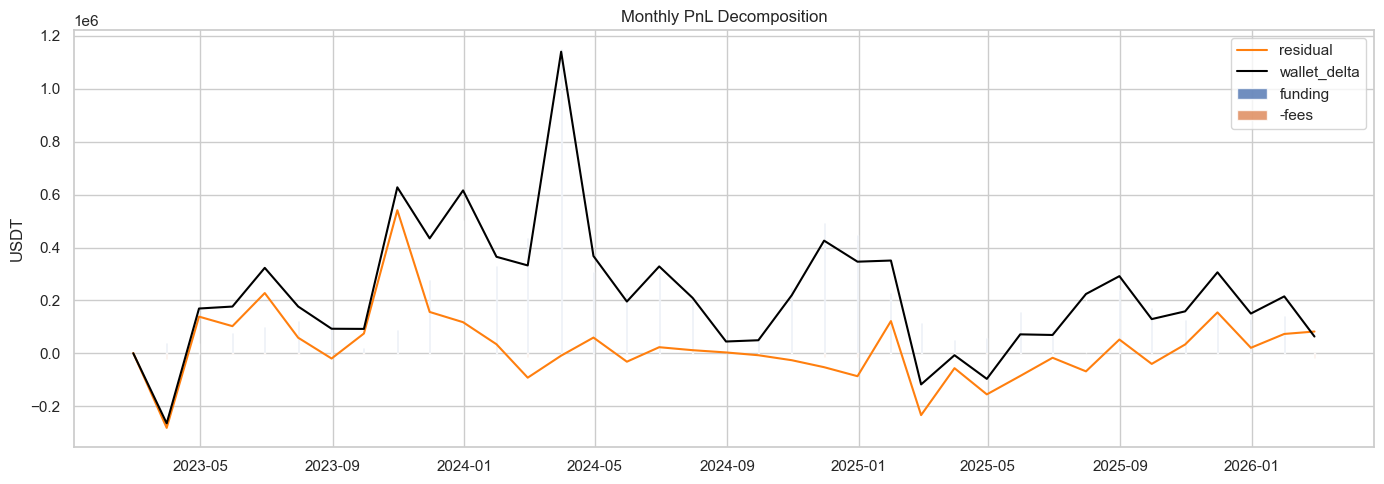

,wallet_delta,funding,fees,residual
datetime,,,,
2025-03-31 00:00:00+00:00,"-7,308.550914","49,327.379125",312.456606,"-56,323.473433"
2025-04-30 00:00:00+00:00,"-96,742.982271","59,609.944005",979.367041,"-155,373.559235"
2025-05-31 00:00:00+00:00,"71,595.006003","157,290.972952",0.000000,"-85,695.966949"
2025-06-30 00:00:00+00:00,"69,256.071698","86,192.217356",0.000000,"-16,936.145658"
2025-07-31 00:00:00+00:00,"224,224.426975","292,537.477046",0.000000,"-68,313.050071"
2025-08-31 00:00:00+00:00,"291,707.515542","239,720.141275",0.000000,"51,987.374267"
2025-09-30 00:00:00+00:00,"129,298.041521","169,449.560632",0.000000,"-40,151.519111"
2025-10-31 00:00:00+00:00,"158,575.042856","125,248.678739",0.000000,"33,326.364116"
2025-11-30 00:00:00+00:00,"306,228.616614","151,637.553953",0.000000,"154,591.062661"


In [7]:

acct = account[["datetime", equity_col]].copy().set_index("datetime").sort_index()
monthly_equity_last = acct[equity_col].resample("ME").last()
monthly_wallet_delta = monthly_equity_last.diff()
monthly_wallet_delta.iloc[0] = monthly_equity_last.iloc[0] - acct[equity_col].iloc[0]

monthly_funding = funding.set_index("datetime")["funding"].resample("ME").sum()
monthly_fees = fills.set_index("datetime")["fee"].resample("ME").sum()

monthly = pd.concat(
    [monthly_wallet_delta.rename("wallet_delta"), monthly_funding.rename("funding"), monthly_fees.rename("fees")],
    axis=1,
).fillna(0.0)
monthly["residual"] = monthly["wallet_delta"] - monthly["funding"] + monthly["fees"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly.index, monthly["funding"], label="funding", alpha=0.8)
ax.bar(monthly.index, -monthly["fees"], label="-fees", alpha=0.8)
ax.plot(monthly.index, monthly["residual"], label="residual", color="tab:orange", lw=1.5)
ax.plot(monthly.index, monthly["wallet_delta"], label="wallet_delta", color="black", lw=1.5)
ax.set_title("Monthly PnL Decomposition")
ax.set_ylabel("USDT")
ax.legend()
plt.tight_layout()
plt.show()

display(monthly.tail(12))



## 6) Funding Regime 分析

### 重點

- Funding rate 正負分佈
- 平均每 8h funding rate 大小
- funding PnL 是否穩定累積

### 解讀方法：

- 正值比例高且均值為正，carry 的大方向才成立
- 若資金費率常態偏負，策略需要明確 gating 或改策略


Settlement count: 3245
Positive ratio: 89.28%
Negative ratio: 10.72%
Mean funding rate per 8h: 0.007438%


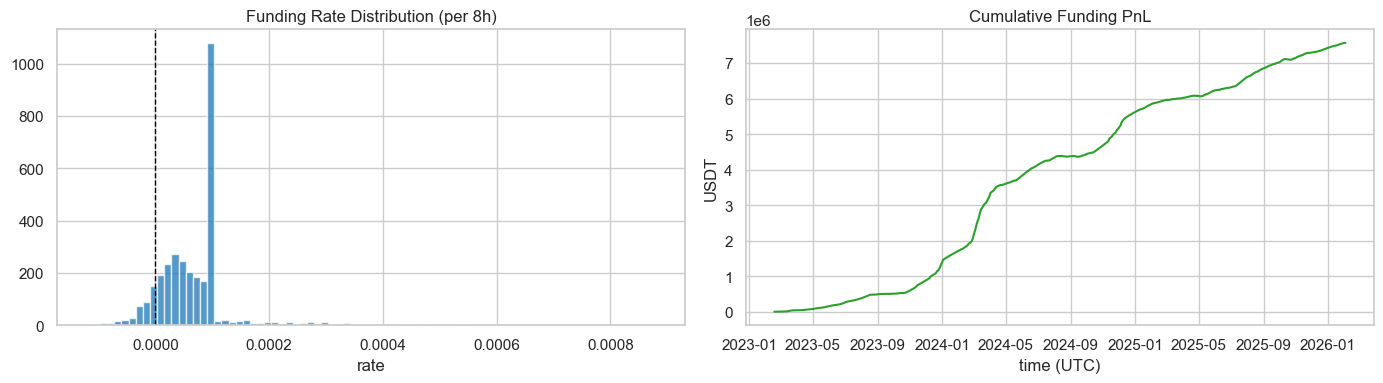

In [8]:

# Funding rate 用 funding_time 去重（同一 settlement 可能有多筆 position funding event）
funding_rate_settlement = (
    funding.groupby("funding_time", as_index=False)
    .agg(rate=("rate", "first"), funding_total=("funding", "sum"))
    .sort_values("funding_time")
)
funding_rate_settlement["funding_dt"] = pd.to_datetime(funding_rate_settlement["funding_time"], unit="ms", utc=True)

positive_ratio = float((funding_rate_settlement["rate"] > 0).mean())
negative_ratio = float((funding_rate_settlement["rate"] < 0).mean())
mean_rate_8h = float(funding_rate_settlement["rate"].mean())

print(f"Settlement count: {len(funding_rate_settlement)}")
print(f"Positive ratio: {positive_ratio:.2%}")
print(f"Negative ratio: {negative_ratio:.2%}")
print(f"Mean funding rate per 8h: {mean_rate_8h:.6%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(funding_rate_settlement["rate"], bins=80, color="tab:blue", alpha=0.75)
axes[0].axvline(0.0, color="black", ls="--", lw=1)
axes[0].set_title("Funding Rate Distribution (per 8h)")
axes[0].set_xlabel("rate")

cum_funding = funding_rate_settlement["funding_total"].cumsum()
axes[1].plot(funding_rate_settlement["funding_dt"], cum_funding, color="tab:green")
axes[1].set_title("Cumulative Funding PnL")
axes[1].set_xlabel("time (UTC)")
axes[1].set_ylabel("USDT")

plt.tight_layout()
plt.show()



## 7) Basis 分析（結構風險來源）

### 重點

- `basis = (perp - spot) / spot`
- basis 的絕對值分位數（p50/p90/p99）
- funding rate 與 basis 的關聯

### 解讀方法：

- basis 波動越大，Residual 漂移風險越高
- funding 與 basis 高相關是常見現象，但不代表每次 basis 大都該交易


Basis |abs| quantiles:
0.500000   0.000445
0.900000   0.000629
0.990000   0.001046
Name: basis_pct, dtype: float64
Funding rate vs basis correlation: 0.7470


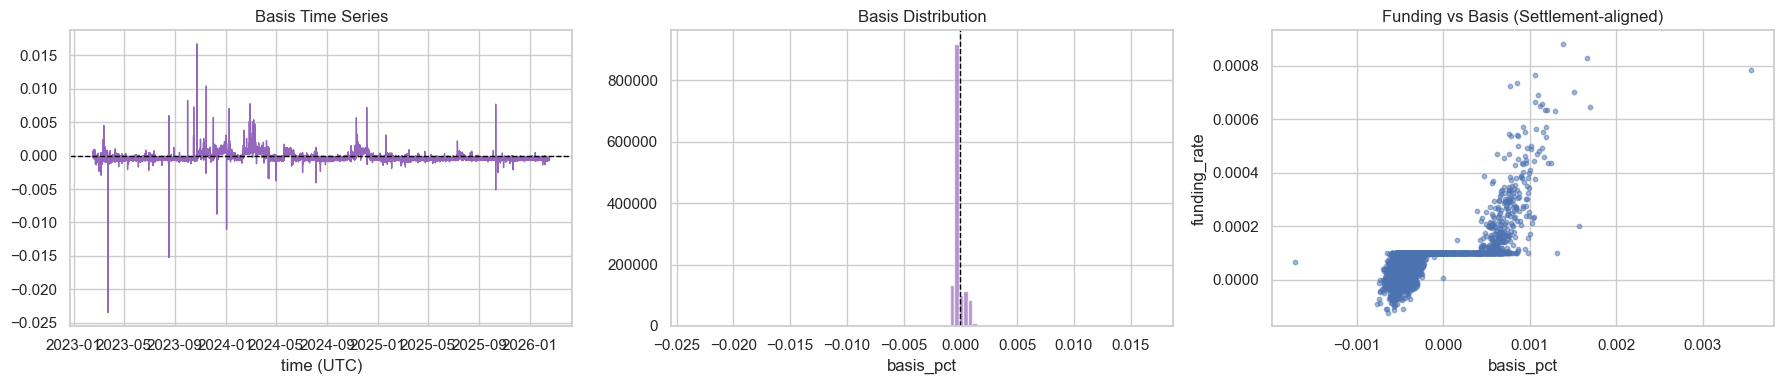

In [9]:

market_k = market[market["has_kline"] == True].copy()
px = (
    market_k.pivot_table(index="ts", columns="symbol", values="close", aggfunc="last")
    .dropna(how="any")
    .reset_index()
)

spot_candidates = [c for c in px.columns if "SPOT" in c]
perp_candidates = [c for c in px.columns if "PERP" in c]
if not spot_candidates or not perp_candidates:
    raise ValueError("Could not find SPOT/PERP symbols in MarketEvent data.")

spot_symbol = spot_candidates[0]
perp_symbol = perp_candidates[0]

px["datetime"] = pd.to_datetime(px["ts"], unit="ms", utc=True)
px["basis_pct"] = (px[perp_symbol] - px[spot_symbol]) / px[spot_symbol]

basis_abs = px["basis_pct"].abs()
print("Basis |abs| quantiles:")
print(basis_abs.quantile([0.5, 0.9, 0.99]))

# 將 settlement funding rate 與同時點附近 basis 對齊
basis_for_merge = px[["datetime", "basis_pct"]].sort_values("datetime")
fund_for_merge = funding_rate_settlement[["funding_dt", "rate"]].sort_values("funding_dt")
merged = pd.merge_asof(
    fund_for_merge,
    basis_for_merge,
    left_on="funding_dt",
    right_on="datetime",
    direction="backward",
)
correlation = merged[["rate", "basis_pct"]].corr().iloc[0, 1]
print(f"Funding rate vs basis correlation: {correlation:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(px["datetime"], px["basis_pct"], color="tab:purple", lw=1)
axes[0].axhline(0.0, color="black", lw=1, ls="--")
axes[0].set_title("Basis Time Series")
axes[0].set_xlabel("time (UTC)")

axes[1].hist(px["basis_pct"], bins=100, color="tab:purple", alpha=0.7)
axes[1].axvline(0.0, color="black", lw=1, ls="--")
axes[1].set_title("Basis Distribution")
axes[1].set_xlabel("basis_pct")

axes[2].scatter(merged["basis_pct"], merged["rate"], s=10, alpha=0.5)
axes[2].set_title("Funding vs Basis (Settlement-aligned)")
axes[2].set_xlabel("basis_pct")
axes[2].set_ylabel("funding_rate")

plt.tight_layout()
plt.show()



## 8) 曝險對齊（Delta-neutral 品質）

### 重點

- `spot_exposure`、`perp_exposure`
- `net_exposure = spot + perp`
- `alignment_ratio = |net| / gross`

### 解讀方法：

- `alignment_ratio` 越小越好（越接近 delta-neutral）
- 若 alignment 長期抬升，表示再平衡頻率或條件可能有問題


Alignment ratio quantiles:
0.500000   0.011869
0.900000   0.038650
0.990000   0.510516
Name: alignment_ratio, dtype: float64


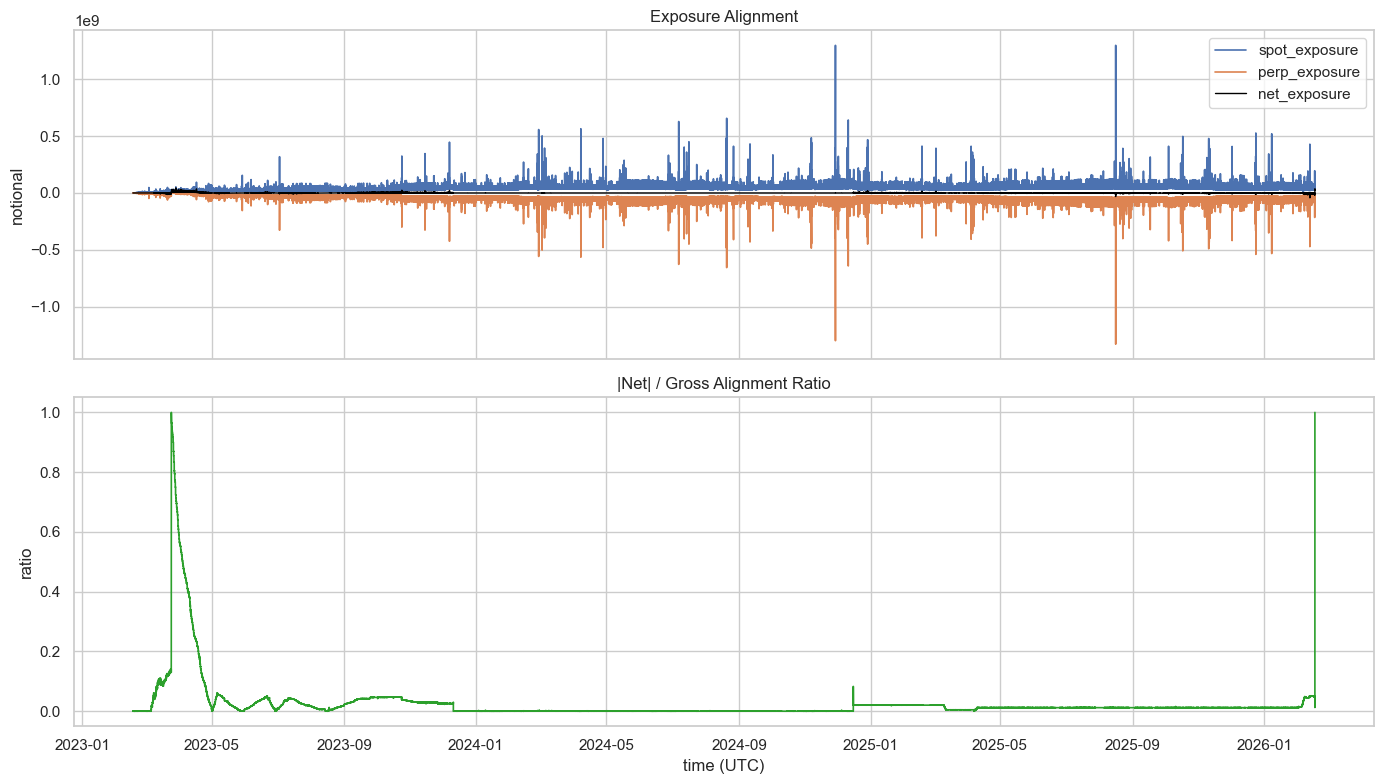

In [10]:

pos = position.copy()
pos["signed_notional"] = np.where(pos["is_long"], 1.0, -1.0) * pos["notional"].abs()

expo = (
    pos.pivot_table(index="datetime", columns="symbol", values="signed_notional", aggfunc="sum")
    .fillna(0.0)
    .sort_index()
)

spot_cols = [c for c in expo.columns if "SPOT" in c]
perp_cols = [c for c in expo.columns if "PERP" in c]
if not spot_cols or not perp_cols:
    raise ValueError("Could not identify SPOT/PERP exposures from Position.arrow.")

exp_df = pd.DataFrame(index=expo.index)
exp_df["spot_exposure"] = expo[spot_cols].sum(axis=1)
exp_df["perp_exposure"] = expo[perp_cols].sum(axis=1)
exp_df["net_exposure"] = exp_df["spot_exposure"] + exp_df["perp_exposure"]
exp_df["gross_exposure"] = exp_df["spot_exposure"].abs() + exp_df["perp_exposure"].abs()
exp_df["alignment_ratio"] = np.where(
    exp_df["gross_exposure"] > 0,
    exp_df["net_exposure"].abs() / exp_df["gross_exposure"],
    np.nan,
)

print("Alignment ratio quantiles:")
print(exp_df["alignment_ratio"].dropna().quantile([0.5, 0.9, 0.99]))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(exp_df.index, exp_df["spot_exposure"], label="spot_exposure", lw=1.2)
axes[0].plot(exp_df.index, exp_df["perp_exposure"], label="perp_exposure", lw=1.2)
axes[0].plot(exp_df.index, exp_df["net_exposure"], label="net_exposure", lw=1.0, color="black")
axes[0].set_title("Exposure Alignment")
axes[0].set_ylabel("notional")
axes[0].legend()

axes[1].plot(exp_df.index, exp_df["alignment_ratio"], color="tab:green", lw=1.2)
axes[1].set_title("|Net| / Gross Alignment Ratio")
axes[1].set_ylabel("ratio")
axes[1].set_xlabel("time (UTC)")

plt.tight_layout()
plt.show()



## 9) 交易活動與成本效率

### 重點

- fill 次數、成交額、費用率（bps）
- taker 比例（若過高，通常費用更重）

### 解讀方法：

- Funding carry 的理想型態是「少量調整 + 長時間持有」
- fill 數突然暴增通常是參數過度敏感或結構失衡


Taker fill ratio: 82.92%


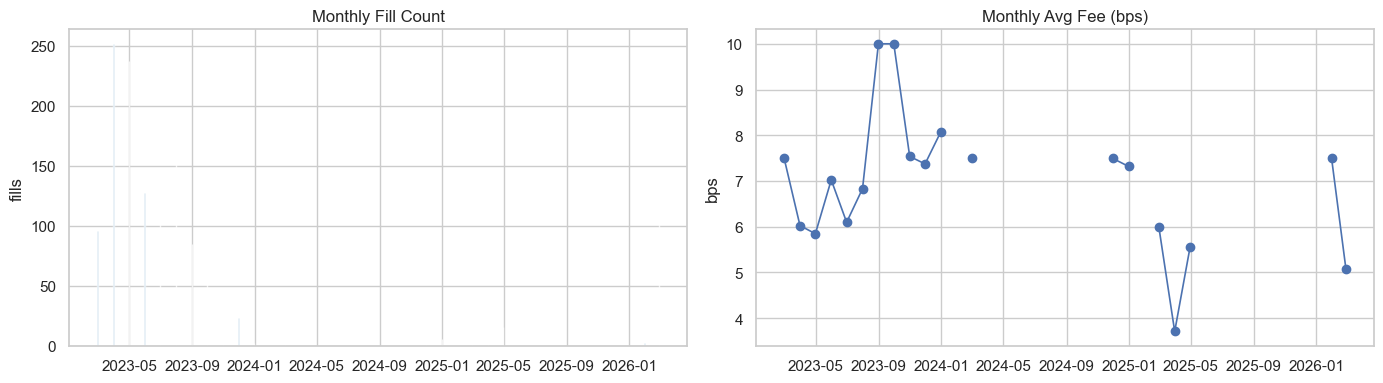

,fill_count,turnover,fees,avg_fee_bps
datetime,,,,
2025-03-31 00:00:00+00:00,7,"842,055.532629",312.456606,3.710641
2025-04-30 00:00:00+00:00,16,"1,763,256.237100",979.367041,5.554309
2025-05-31 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-06-30 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-07-31 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-08-31 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-09-30 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-10-31 00:00:00+00:00,0,0.000000,0.000000,NaN
2025-11-30 00:00:00+00:00,0,0.000000,0.000000,NaN


In [11]:

fills = fills.copy()
fills["fee_bps"] = np.where(fills["notional"] > 0, fills["fee"].abs() / fills["notional"] * 1e4, np.nan)

monthly_trades = pd.DataFrame(index=fills.set_index("datetime").resample("ME").size().index)
monthly_trades["fill_count"] = fills.set_index("datetime").resample("ME").size()
monthly_trades["turnover"] = fills.set_index("datetime")["notional"].resample("ME").sum()
monthly_trades["fees"] = fills.set_index("datetime")["fee"].resample("ME").sum()
monthly_trades["avg_fee_bps"] = np.where(
    monthly_trades["turnover"] > 0,
    monthly_trades["fees"].abs() / monthly_trades["turnover"] * 1e4,
    np.nan,
)

if "is_taker" in fills.columns:
    taker_ratio = float(fills["is_taker"].fillna(False).mean())
    print(f"Taker fill ratio: {taker_ratio:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(monthly_trades.index, monthly_trades["fill_count"], color="tab:blue", alpha=0.75)
axes[0].set_title("Monthly Fill Count")
axes[0].set_ylabel("fills")

axes[1].plot(monthly_trades.index, monthly_trades["avg_fee_bps"], marker="o", lw=1.2)
axes[1].set_title("Monthly Avg Fee (bps)")
axes[1].set_ylabel("bps")

plt.tight_layout()
plt.show()

display(monthly_trades.tail(12))


## 10) CarryDecisionEvent（策略決策與執行落差）

### 重點

- `submit_rate`：策略有 gap 時，實際下單比例
- `significant_gap_no_submit_rate`：gap 已經很大但仍不下單的比例
- `positive_funding_and_no_submit_rate`：在正 funding 情境下仍錯過的比例
- `per-symbol` 的 `avg_abs_gap_notional` 與 `avg_submitted_abs_notional`

### 解讀方法：

- 如果 `significant_gap_no_submit_rate` 很高，通常代表 gate / no-trade band / cooldown 太嚴
- 如果 `positive_funding_and_no_submit_rate` 高，代表吃不到該吃的 funding
- 如果 `avg_abs_gap_notional` 很大但 `avg_submitted_abs_notional` 很小，代表執行強度不足（節奏太慢）


In [12]:
carry_event_path = RUN_DIR / "CarryDecisionEvent.arrow"

if not carry_event_path.exists():
    display(Markdown("### ℹ️ 此 run 沒有 CarryDecisionEvent.arrow（可能是舊版 run）。"))
else:
    carry = read_arrow("CarryDecisionEvent.arrow")

    if carry.empty:
        display(Markdown("### ℹ️ CarryDecisionEvent 存在，但資料列為 0。"))
    else:
        # market_ts_ms 為主要時間欄位；若是舊資料則回退到 ts。
        ts_col = "market_ts_ms" if "market_ts_ms" in carry.columns else "ts"
        carry["datetime"] = pd.to_datetime(carry[ts_col], unit="ms", utc=True)

        carry["abs_gap_notional"] = carry["gap_notional"].abs()
        carry["has_submission"] = carry["submitted_order_count"] > 0
        carry["submitted_abs_notional"] = carry["submitted_notional"].abs()
        carry["positive_funding"] = carry["observed_funding_rate"] > 0

        p75_gap = float(carry["abs_gap_notional"].quantile(0.75))
        significant_gap = carry["abs_gap_notional"] >= p75_gap if p75_gap > 0 else (carry["abs_gap_notional"] > 0)
        significant_gap_no_submit = significant_gap & (~carry["has_submission"])

        overview = pd.DataFrame(
            {
                "metric": [
                    "rows",
                    "submit_rate",
                    "funding_available_rate",
                    "positive_funding_share",
                    "avg_abs_gap_notional",
                    "median_abs_gap_notional",
                    "avg_submitted_abs_notional",
                    "significant_gap_threshold_abs_notional_p75",
                    "significant_gap_no_submit_rate",
                    "positive_funding_and_no_submit_rate",
                ],
                "value": [
                    int(len(carry)),
                    float(carry["has_submission"].mean()),
                    float(carry["funding_available"].mean()) if "funding_available" in carry.columns else np.nan,
                    float(carry["positive_funding"].mean()),
                    float(carry["abs_gap_notional"].mean()),
                    float(carry["abs_gap_notional"].median()),
                    float(carry["submitted_abs_notional"].mean()),
                    p75_gap,
                    float(significant_gap_no_submit.mean()),
                    float((carry["positive_funding"] & significant_gap_no_submit).mean()),
                ],
            }
        )
        display(overview)

        by_symbol = (
            carry.groupby("symbol", as_index=False)
            .agg(
                rows=("symbol", "size"),
                submit_rate=("has_submission", "mean"),
                avg_abs_gap_notional=("abs_gap_notional", "mean"),
                median_abs_gap_notional=("abs_gap_notional", "median"),
                avg_submitted_abs_notional=("submitted_abs_notional", "mean"),
                positive_funding_share=("positive_funding", "mean"),
            )
            .sort_values("rows", ascending=False)
        )
        display(by_symbol)

        daily = (
            carry.set_index("datetime")
            .resample("D")
            .agg(
                submit_rate=("has_submission", "mean"),
                avg_abs_gap_notional=("abs_gap_notional", "mean"),
            )
            .dropna(how="all")
        )

        fig, axes = plt.subplots(1, 2, figsize=(16, 4))

        axes[0].plot(daily.index, daily["submit_rate"], color="tab:blue", lw=1.2)
        axes[0].set_title("Daily Submit Rate")
        axes[0].set_ylabel("ratio")
        axes[0].set_xlabel("time (UTC)")

        bins = 60
        axes[1].hist(carry.loc[carry["has_submission"], "abs_gap_notional"], bins=bins, alpha=0.7, label="submitted")
        axes[1].hist(carry.loc[~carry["has_submission"], "abs_gap_notional"], bins=bins, alpha=0.7, label="not_submitted")
        axes[1].set_title("Gap Notional Distribution: Submitted vs Not Submitted")
        axes[1].set_xlabel("abs_gap_notional")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        missed = carry.loc[
            significant_gap_no_submit & carry["positive_funding"],
            ["datetime", "symbol", "observed_funding_rate", "abs_gap_notional", "signal_confidence", "submitted_order_count"],
        ].sort_values("abs_gap_notional", ascending=False)

        display(Markdown("#### Top missed opportunities (positive funding + significant gap + no submit)"))
        display(missed.head(20))


### ℹ️ 此 run 沒有 CarryDecisionEvent.arrow（可能是舊版 run）。


## 11) 一頁式判讀清單（Go / No-Go）

### 重點

- 這個 baseline 是否符合 carry 策略核心品質

### 解讀方法：

- 下面每個條件都是實務上常用的最低品質門檻
- 若紅燈太多，不建議直接拿去做參數擴展


In [13]:

checks = [
    ("Annualized return > 0", annualized_return_pct > 0),
    ("Funding sum > 0", funding_sum > 0),
    ("Funding sum > total fees", funding_sum > total_fees),
    ("Residual/Funding <= 0.25", residual_to_funding <= 0.25),
    ("Max drawdown >= -5%", max_drawdown_pct >= -0.05),
    ("Return/Fee > 50", return_to_fees > 50),
    ("Exposure alignment p90 <= 1%", exp_df["alignment_ratio"].dropna().quantile(0.9) <= 0.01),
]

check_df = pd.DataFrame(checks, columns=["check", "pass"])
check_df["status"] = np.where(check_df["pass"], "PASS", "FAIL")
display(check_df)

if check_df["pass"].all():
    display(Markdown("### ✅ Baseline quality looks healthy for Stage-1 carry."))
else:
    display(Markdown("### ⚠️ Baseline has quality gaps. Check failed items before next optimization stage."))


,check,pass,status
0,Annualized return > 0,True,PASS
1,Funding sum > 0,True,PASS
2,Funding sum > total fees,True,PASS
3,Residual/Funding <= 0.25,True,PASS
4,Max drawdown >= -5%,True,PASS
5,Return/Fee > 50,True,PASS
6,Exposure alignment p90 <= 1%,False,FAIL


### ⚠️ Baseline has quality gaps. Check failed items before next optimization stage.


## 12) Funding Capture Efficiency（有沒有吃到該吃的 funding）

這段要回答一個核心問題：

- 市場上「可收 funding」的時段有多少？
- 我們實際「有持倉而吃到 funding」的時段有多少？

> 如果 capture ratio 長期偏低，就代表策略 gate / 進出場 / 持倉穩定性有改善空間。


In [14]:

import json

run_meta_path = RUN_DIR / "run_metadata.json"
funding_csv_path = None

if run_meta_path.exists():
    run_meta = json.loads(run_meta_path.read_text(encoding="utf-8"))
    dataset = run_meta.get("dataset", "")
    for part in str(dataset).split(";"):
        if "|" in part:
            funding_csv_path = part.split("|", 1)[1]
            break

full_funding = None
if funding_csv_path is not None:
    try:
        full_funding = pd.read_csv(funding_csv_path)
    except Exception as e:
        print(f"Failed to read funding csv: {e}")

if full_funding is None or full_funding.empty:
    display(Markdown("**Funding history csv 無法載入，跳過 capture efficiency 分析。**"))
else:
    # 嘗試自動識別欄位名稱
    time_candidates = ["funding_time", "fundingTime", "timestamp", "time", "ts"]
    rate_candidates = ["rate", "funding_rate", "fundingRate"]

    time_col = next((c for c in time_candidates if c in full_funding.columns), None)
    rate_col = next((c for c in rate_candidates if c in full_funding.columns), None)

    if time_col is None or rate_col is None:
        display(Markdown(f"**Funding csv 欄位不符預期，columns={list(full_funding.columns)}**"))
    else:
        ff = full_funding[[time_col, rate_col]].copy()
        ff = ff.rename(columns={time_col: "funding_time", rate_col: "rate"})
        ff["funding_time"] = pd.to_numeric(ff["funding_time"], errors="coerce")
        ff["rate"] = pd.to_numeric(ff["rate"], errors="coerce")
        ff = ff.dropna(subset=["funding_time", "rate"]).copy()

        run_start_ts = float(account["timestamp"].min())
        run_end_ts = float(account["timestamp"].max())
        ff = ff[(ff["funding_time"] >= run_start_ts) & (ff["funding_time"] <= run_end_ts)].copy()
        ff = ff.sort_values("funding_time").drop_duplicates(subset=["funding_time"], keep="last")

        captured = (
            funding_rate_settlement[["funding_time", "rate"]]
            .drop_duplicates(subset=["funding_time"], keep="last")
            .copy()
        )
        captured["captured"] = 1

        comp = ff.merge(captured[["funding_time", "captured"]], on="funding_time", how="left")
        comp["captured"] = comp["captured"].fillna(0).astype(int)
        comp["is_positive"] = comp["rate"] > 0

        total_settlements = int(len(comp))
        total_positive = int(comp["is_positive"].sum())
        captured_settlements = int(comp["captured"].sum())
        captured_positive = int(((comp["captured"] == 1) & comp["is_positive"]).sum())

        capture_ratio_all = captured_settlements / total_settlements if total_settlements > 0 else np.nan
        capture_ratio_pos = captured_positive / total_positive if total_positive > 0 else np.nan

        capture_summary = pd.DataFrame([
            {"metric": "total_settlements_in_run", "value": total_settlements},
            {"metric": "positive_settlements_in_run", "value": total_positive},
            {"metric": "captured_settlements", "value": captured_settlements},
            {"metric": "captured_positive_settlements", "value": captured_positive},
            {"metric": "capture_ratio_all", "value": capture_ratio_all},
            {"metric": "capture_ratio_positive_only", "value": capture_ratio_pos},
        ])
        display(capture_summary)

        comp["funding_dt"] = pd.to_datetime(comp["funding_time"], unit="ms", utc=True)
        comp["month"] = comp["funding_dt"].dt.to_period("M").dt.to_timestamp()

        monthly_cap = comp.groupby("month", as_index=False).agg(
            total_settlements=("funding_time", "count"),
            positive_settlements=("is_positive", "sum"),
            captured_settlements=("captured", "sum"),
            captured_positive_settlements=("captured", lambda s: int(s[comp.loc[s.index, "is_positive"] == 1].sum())),
        )
        monthly_cap["capture_ratio_positive"] = np.where(
            monthly_cap["positive_settlements"] > 0,
            monthly_cap["captured_positive_settlements"] / monthly_cap["positive_settlements"],
            np.nan,
        )

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].plot(monthly_cap["month"], monthly_cap["positive_settlements"], label="positive settlements (market)", lw=1.5)
        axes[0].plot(monthly_cap["month"], monthly_cap["captured_positive_settlements"], label="captured positive settlements", lw=1.5)
        axes[0].set_title("Positive Funding Settlement Coverage")
        axes[0].legend()

        axes[1].plot(monthly_cap["month"], monthly_cap["capture_ratio_positive"], color="tab:purple", lw=1.5)
        axes[1].axhline(0.5, ls="--", color="gray", lw=1)
        axes[1].set_title("Positive Funding Capture Ratio")
        axes[1].set_ylim(0, 1)

        plt.tight_layout()
        plt.show()


**Funding csv 欄位不符預期，columns=['FundingTime', 'Rate', 'MarkPrice']**


### 解讀方法：

- `capture_ratio_positive_only` 越高越好，代表你更常在「正 funding」時段持倉。
- 如果市場正 funding 很多，但捕捉率低：
  - gate 可能過嚴
  - 持倉容易被打掉（churn 太高）
  - 或進場太慢（cooldown / persistence 太長）



## 13) Daily Efficiency Dashboard（每天到底賺在哪 / 虧在哪）

把每日損益拆成四塊：

- `wallet_delta`: 每日總變化
- `funding`: 資金費收益
- `fees`: 手續費
- `residual`: 價差/滑價/未解釋部分


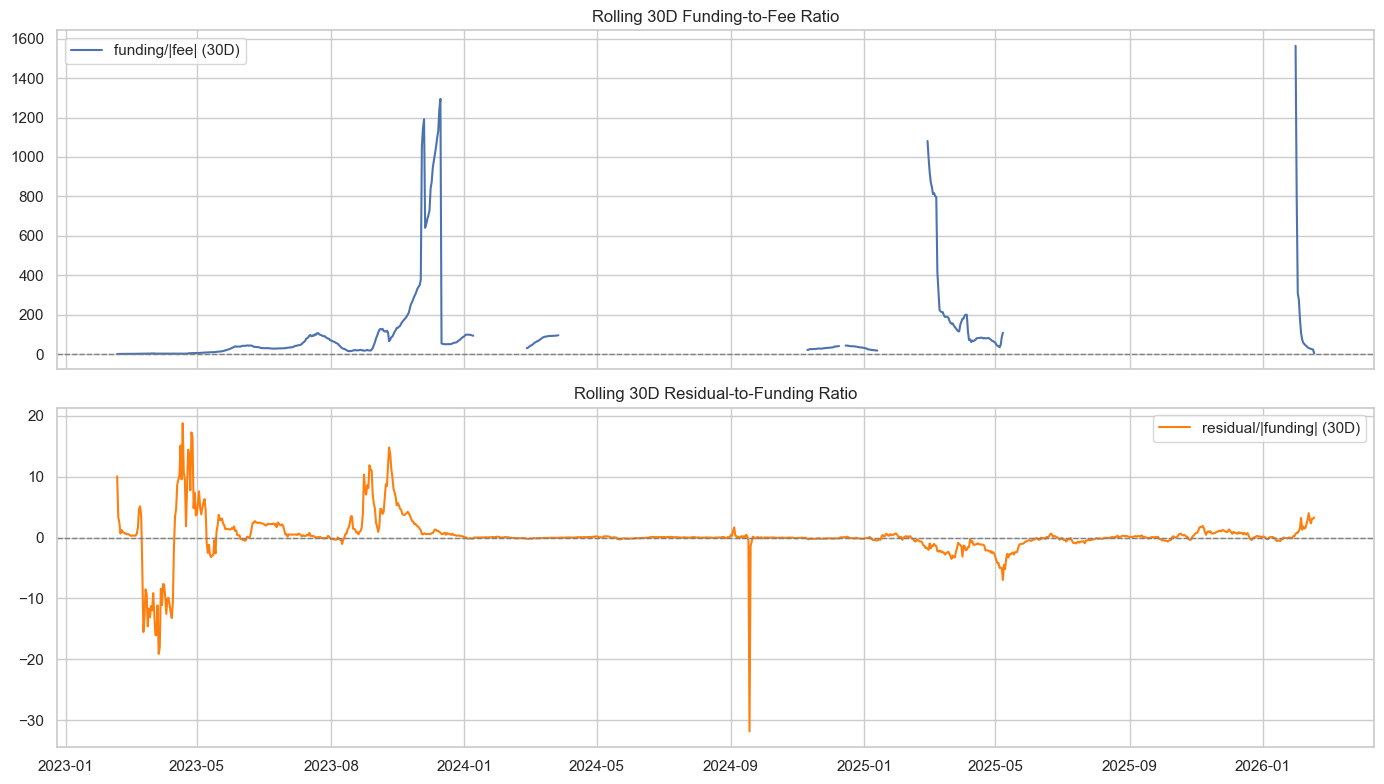

,wallet_delta,funding,fees,residual,funding_to_fee,residual_to_funding
datetime,,,,,,
2026-02-08 00:00:00+00:00,"-32,268.092427",0.000000,194.257085,"-32,073.835343",0.000000,NaN
2026-02-09 00:00:00+00:00,621.005033,0.000000,119.893461,740.898494,0.000000,NaN
2026-02-10 00:00:00+00:00,"44,889.481668",0.000000,87.767362,"44,977.249029",0.000000,NaN
2026-02-11 00:00:00+00:00,"54,210.045885",0.000000,323.065391,"54,533.111276",0.000000,NaN
2026-02-12 00:00:00+00:00,"27,720.433702",0.000000,133.315559,"27,853.749261",0.000000,NaN
2026-02-13 00:00:00+00:00,"-99,260.223731",0.000000,89.682488,"-99,170.541242",0.000000,NaN
2026-02-14 00:00:00+00:00,"-39,164.974993",0.000000,89.510131,"-39,075.464863",0.000000,NaN
2026-02-15 00:00:00+00:00,"40,355.159178",0.000000,48.579930,"40,403.739108",0.000000,NaN
2026-02-16 00:00:00+00:00,"-3,753.778818",0.000000,130.393837,"-3,623.384981",0.000000,NaN


In [15]:

daily_equity = account[["datetime", equity_col]].copy().set_index("datetime").sort_index()
daily_wallet = daily_equity[equity_col].resample("D").last().diff().fillna(0.0)

daily_funding = funding.set_index("datetime")["funding"].resample("D").sum().fillna(0.0)
daily_fees = fills.set_index("datetime")["fee"].resample("D").sum().fillna(0.0)

daily = pd.concat([
    daily_wallet.rename("wallet_delta"),
    daily_funding.rename("funding"),
    daily_fees.rename("fees"),
], axis=1).fillna(0.0)

daily["residual"] = daily["wallet_delta"] - daily["funding"] + daily["fees"]
daily["funding_to_fee"] = np.where(daily["fees"].abs() > 1e-12, daily["funding"] / daily["fees"].abs(), np.nan)
daily["residual_to_funding"] = np.where(daily["funding"].abs() > 1e-12, daily["residual"] / daily["funding"].abs(), np.nan)

daily_roll = daily[["funding", "fees", "residual"]].rolling(30, min_periods=10).sum()
daily_roll["funding_fee_ratio_30d"] = np.where(
    daily_roll["fees"].abs() > 1e-12,
    daily_roll["funding"] / daily_roll["fees"].abs(),
    np.nan,
)
daily_roll["residual_funding_ratio_30d"] = np.where(
    daily_roll["funding"].abs() > 1e-12,
    daily_roll["residual"] / daily_roll["funding"].abs(),
    np.nan,
)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily_roll.index, daily_roll["funding_fee_ratio_30d"], label="funding/|fee| (30D)", lw=1.5)
axes[0].axhline(1.0, ls="--", lw=1, color="gray")
axes[0].set_title("Rolling 30D Funding-to-Fee Ratio")
axes[0].legend()

axes[1].plot(daily_roll.index, daily_roll["residual_funding_ratio_30d"], label="residual/|funding| (30D)", lw=1.5, color="tab:orange")
axes[1].axhline(0.0, ls="--", lw=1, color="gray")
axes[1].set_title("Rolling 30D Residual-to-Funding Ratio")
axes[1].legend()

plt.tight_layout()
plt.show()

display(daily.tail(10))



### 解讀方法：

- `funding/|fee| (30D)`：長期應該大於 1，越大越健康。
- `residual/|funding| (30D)`：越靠近 0 越好；絕對值過大表示價格漂移/執行品質在吞噬 carry。



## 14) Rebalance / Churn 診斷（是不是交易太碎）

這段用 fill 層面觀察：

- 每日買賣 notional 是否失衡（越失衡越可能不是中性對沖）
- 平均單筆 notional 是否太小（太小常見於過度修正）


**`side` 欄位不存在：此 run 無法計算買賣失衡比（imbalance ratio）。**

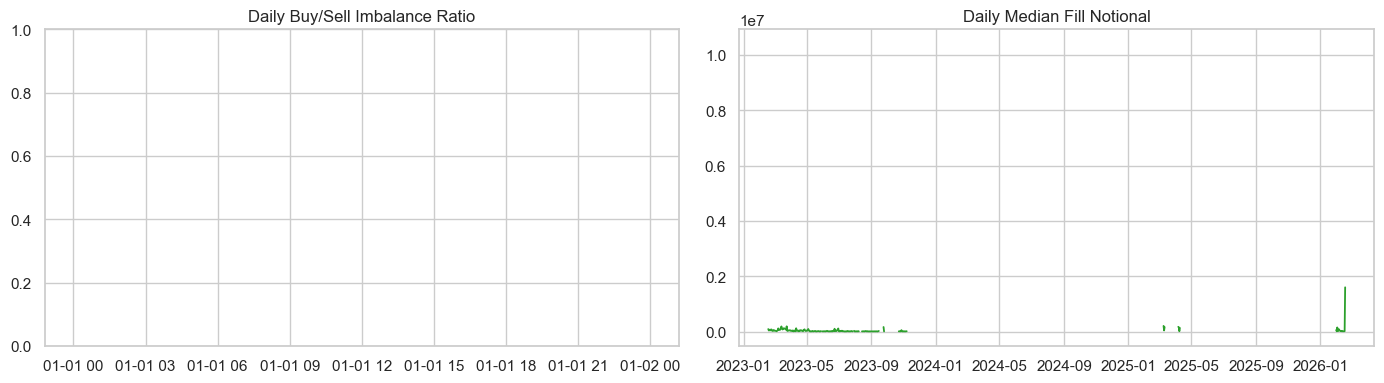

,count,mean,std,min,25%,50%,75%,max
fill_count,"1,097.000000",1.237922,2.552532,0.000000,0.000000,0.000000,0.000000,14.000000
turnover,"1,097.000000","153,531.099801","1,371,156.632326",0.000000,0.000000,0.000000,0.000000,"27,246,778.628760"
median_fill_notional,254.000000,"136,028.474221","866,217.205690","8,679.247871","12,109.371194","18,619.680780","42,160.911837","10,396,112.917946"
signed_notional,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
imbalance_ratio,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:

if fills.empty:
    display(Markdown("**No fills found.**"))
else:
    f = fills.copy()

    # 先嘗試從 fills / order_event 取得 side。
    # 若資料沒有 side（舊 schema），就只做 turnover 與單筆大小分析，略過 imbalance。
    if "side" in f.columns:
        side_series = f["side"].astype(str)
    elif "side" in order_event.columns:
        # 以常用欄位做近似 merge，補 side
        key_cols = ["datetime", "symbol", "exec_qty", "exec_price", "fee"]
        left_cols = [k for k in key_cols if k in f.columns]
        right_cols = [k for k in key_cols if k in order_event.columns]
        use_cols = [k for k in key_cols if k in left_cols and k in right_cols]

        if use_cols:
            oe = order_event[order_event["exec_qty"] > 0][use_cols + ["side"]].copy()
            f = f.merge(oe, on=use_cols, how="left")
            side_series = f["side"].astype(str)
        else:
            side_series = None
    else:
        side_series = None

    by_day = f.set_index("datetime").resample("D").agg(
        fill_count=("notional", "count"),
        turnover=("notional", "sum"),
        median_fill_notional=("notional", "median"),
    )

    if side_series is not None:
        side_sign = np.where(side_series.str.upper().str.contains("BUY", na=False), 1.0,
                             np.where(side_series.str.upper().str.contains("SELL", na=False), -1.0, np.nan))
        f["signed_notional"] = f["notional"] * pd.Series(side_sign, index=f.index).fillna(0.0)
        signed_by_day = f.set_index("datetime")["signed_notional"].resample("D").sum()
        by_day = by_day.join(signed_by_day, how="left")
        by_day["imbalance_ratio"] = np.where(
            by_day["turnover"] > 0,
            by_day["signed_notional"].abs() / by_day["turnover"],
            np.nan,
        )
    else:
        by_day["signed_notional"] = np.nan
        by_day["imbalance_ratio"] = np.nan
        display(Markdown("**`side` 欄位不存在：此 run 無法計算買賣失衡比（imbalance ratio）。**"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(by_day.index, by_day["imbalance_ratio"], lw=1.3)
    axes[0].set_title("Daily Buy/Sell Imbalance Ratio")
    axes[0].set_ylim(0, 1)

    axes[1].plot(by_day.index, by_day["median_fill_notional"], lw=1.3, color="tab:green")
    axes[1].set_title("Daily Median Fill Notional")

    plt.tight_layout()
    plt.show()

    display(by_day.describe().T)



### 解讀方法：

- `imbalance_ratio` 長期偏高：代表執行腿可能不對稱，會讓 residual 擴大。
- `median_fill_notional` 過小：常見於太敏感地頻繁修正（高 churn）。



## 15) 半年 Regime 切片（市場變了沒）

前面提到「市場會變」，這裡用半年切片看：

- funding 結構（正負比例、平均、波動）
- 策略結果（period return）

目標：找出「什麼 regime 對這組參數友善/不友善」。


C:\Users\Kenneth\AppData\Local\Temp\2\ipykernel_18944\1246581860.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  regime_src["half_year"] = regime_src["dt"].dt.to_period("2Q").astype(str)
C:\Users\Kenneth\AppData\Local\Temp\2\ipykernel_18944\1246581860.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  acct["half_year"] = acct["datetime"].dt.to_period("2Q").astype(str)


,half_year,settlement_count,pos_share,neg_share,mean_rate,std_rate,period_return_pct
0,2023Q1,127,0.889764,0.110236,0.000060,0.000055,-0.264843
1,2023Q2,273,0.919414,0.080586,0.000057,0.000039,0.666710
2,2023Q3,276,0.807971,0.192029,0.000043,0.000046,0.357626
3,2023Q4,276,0.934783,0.065217,0.000111,0.000097,1.665656
4,2024Q1,273,1.000000,0.000000,0.000204,0.000169,1.784821
5,2024Q2,273,0.948718,0.051282,0.000085,0.000062,0.852226
6,2024Q3,276,0.739130,0.260870,0.000032,0.000051,0.283947
7,2024Q4,276,0.978261,0.021739,0.000116,0.000081,0.938257
8,2025Q1,270,0.870370,0.129630,0.000048,0.000041,0.216373
9,2025Q2,273,0.813187,0.186813,0.000032,0.000041,0.039037


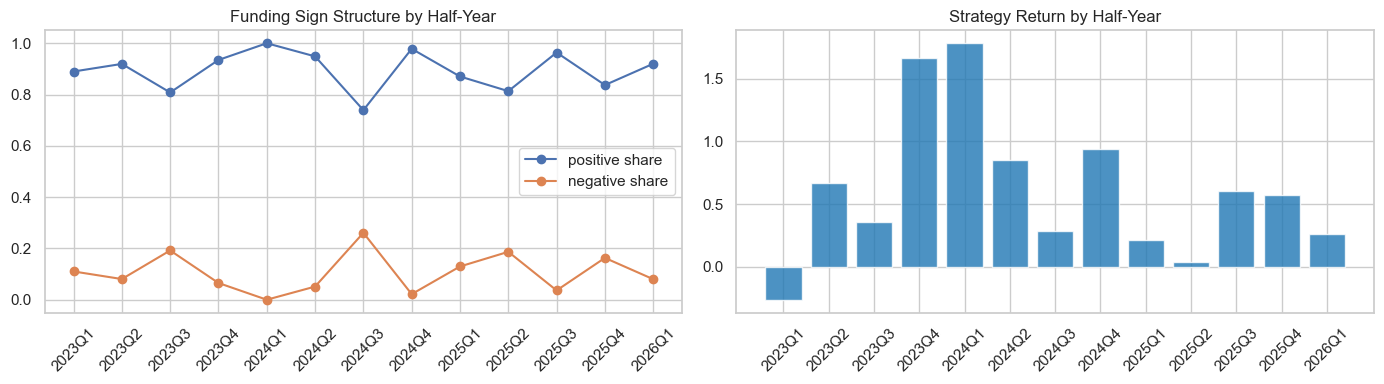

In [17]:

# 使用 full funding history（如果上面成功載入），否則退回 funding events
if 'ff' in globals() and ff is not None and not ff.empty:
    regime_src = ff.copy()
    regime_src["dt"] = pd.to_datetime(regime_src["funding_time"], unit="ms", utc=True)
else:
    regime_src = funding_rate_settlement[["funding_time", "rate"]].copy()
    regime_src["dt"] = pd.to_datetime(regime_src["funding_time"], unit="ms", utc=True)

regime_src["half_year"] = regime_src["dt"].dt.to_period("2Q").astype(str)

funding_regime = regime_src.groupby("half_year", as_index=False).agg(
    settlement_count=("rate", "count"),
    pos_share=("rate", lambda s: float((s > 0).mean())),
    neg_share=("rate", lambda s: float((s < 0).mean())),
    mean_rate=("rate", "mean"),
    std_rate=("rate", "std"),
)

# 同期間的 equity return
acct = account[["datetime", equity_col]].copy().sort_values("datetime")
acct["half_year"] = acct["datetime"].dt.to_period("2Q").astype(str)
ret_by_regime = acct.groupby("half_year", as_index=False).agg(
    start_equity=(equity_col, "first"),
    end_equity=(equity_col, "last"),
)
ret_by_regime["period_return_pct"] = np.where(
    ret_by_regime["start_equity"] > 0,
    (ret_by_regime["end_equity"] / ret_by_regime["start_equity"] - 1.0) * 100,
    np.nan,
)

regime_panel = funding_regime.merge(ret_by_regime[["half_year", "period_return_pct"]], on="half_year", how="left")
regime_panel = regime_panel.sort_values("half_year")

display(regime_panel)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(regime_panel["half_year"], regime_panel["pos_share"], marker="o", label="positive share")
axes[0].plot(regime_panel["half_year"], regime_panel["neg_share"], marker="o", label="negative share")
axes[0].set_title("Funding Sign Structure by Half-Year")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].bar(regime_panel["half_year"], regime_panel["period_return_pct"], color="tab:blue", alpha=0.8)
axes[1].set_title("Strategy Return by Half-Year")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()



### 解讀方法：

- 如果某些半年 `neg_share` 明顯上升、同時 `period_return_pct` 下滑，代表舊參數可能失效。
- 這就是你要做動態參數（或 regime-aware gate）的依據。